## Intrusion Detection System For Internet of Things (IoT) Using Machine Learning

- Importing Neccessary Libraries

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns  
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.feature_selection import chi2, mutual_info_classif, SelectKBest
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV


import warnings
warnings.simplefilter('ignore')

### Preprocessing the traning dataset

In [65]:
# Reading the Training dateset
url_1 = 'Datasets/kdd_train.csv'
data_train = pd.read_csv(url_1)
data_train.head(3)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune


In [66]:
# Checking the number of instances and features in the dataset
data_train.shape

(125973, 42)

- Changing the Multi-Class Target class of the Training set to a Binary Class 

In [67]:
# merging target class
data_target1 = data_train[['labels']]


data_target1['labels'] = data_target1['labels'].replace(
    {label: 'abnormal' for label in data_target1['labels'].unique() if label != 'normal'}
)
print(data_target1)

          labels
0         normal
1         normal
2       abnormal
3         normal
4         normal
...          ...
125968  abnormal
125969    normal
125970    normal
125971  abnormal
125972    normal

[125973 rows x 1 columns]


In [68]:
data_train = data_train.drop(['labels'], axis = 1)
data_train = pd.concat([data_train, data_target1], axis = 1)
data_train

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,abnormal
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,25,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,abnormal
125969,8,udp,private,SF,105,145,0,0,0,0,...,244,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,30,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,8,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,abnormal


In [69]:
list(data_train.labels.unique())

['normal', 'abnormal']

In [70]:
data_train.labels.value_counts()

labels
normal      67343
abnormal    58630
Name: count, dtype: int64

<Axes: xlabel='labels'>

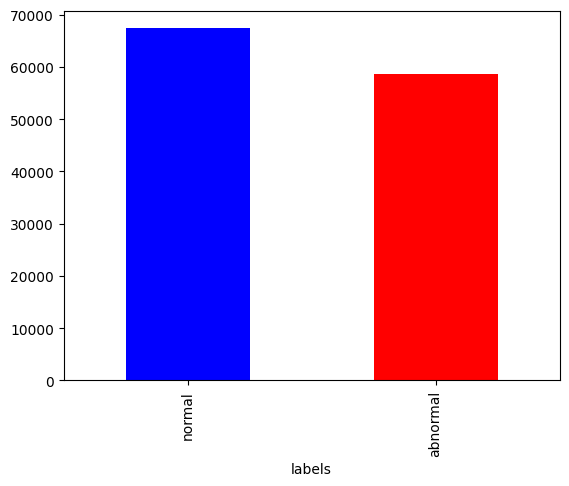

In [71]:
# Plotting the distribution of the Target class in in the Training set
data_train.labels.value_counts().plot(kind = 'bar', color = ['b','r'])

- checking for missing values

In [72]:
# Missing Values
data_train.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [73]:
data_train.dtypes

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

- Label Encoding the training dataset

In [74]:
label = LabelEncoder()
data_train['protocol_type'] = label.fit_transform(data_train['protocol_type'])
data_train['service'] = label.fit_transform(data_train['service'])
data_train['flag'] = label.fit_transform(data_train['flag'])
data_train['labels'] = label.fit_transform(data_train['labels'])
data_train.sample(4)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
30840,1,1,24,9,248,1856,0,0,0,1,...,250,0.98,0.01,0.00,0.00,0.0,0.0,0.0,0.0,1
33637,0,1,32,1,0,0,0,0,0,0,...,4,0.02,0.08,0.00,0.00,0.0,0.0,1.0,1.0,0
72205,0,0,14,9,8,0,0,0,0,0,...,26,1.00,0.00,1.00,0.50,0.0,0.0,0.0,0.0,0
3620,0,1,24,9,220,337,0,0,0,0,...,255,1.00,0.00,0.01,0.01,0.0,0.0,0.0,0.0,1


In [75]:
# Separting features from target 
features_train = data_train.drop(['labels'], axis = 1)
target_train = data_train.loc[:,['labels']]

In [76]:
# target_train

### Preprocessing testing data

In [77]:
# Reading the dataset
url_2  = 'Datasets/kdd_test.csv'
data_test = pd.read_csv(url_2)
data_test.head(4)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,5,tcp,smtp,SF,2429,475,0,0,0,0,...,57,0.11,0.02,0.01,0.04,0.0,0.0,0.87,0.0,normal
1,0,udp,domain_u,SF,45,134,0,0,0,0,...,155,0.80,0.02,0.01,0.00,0.0,0.0,0.00,0.0,normal
2,0,udp,domain_u,SF,45,80,0,0,0,0,...,255,1.00,0.00,0.01,0.00,0.0,0.0,0.00,0.0,normal
3,1979,udp,other,SF,145,105,0,0,0,0,...,2,0.01,0.84,1.00,0.00,0.0,0.0,0.00,0.0,normal


In [78]:
data_test.labels.unique()

array(['normal', 'portsweep', 'neptune', 'smurf', 'satan', 'apache2',
       'teardrop', 'guess_passwd', 'ipsweep', 'warezclient', 'nmap',
       'warezmaster', 'mscan', 'back', 'pod', 'httptunnel',
       'processtable', 'mailbomb', 'snmpguess', 'saint', 'multihop',
       'snmpgetattack', 'buffer_overflow', 'xsnoop', 'imap', 'ps',
       'rootkit', 'land', 'xterm', 'sendmail', 'phf', 'loadmodule',
       'perl', 'xlock', 'ftp_write', 'named'], dtype=object)

In [79]:
# Checking the number of Instances and features in the Testing set
data_test.shape

(22544, 42)

- Changing the Multi-Class Target class of the Testing set to a Binary Class 

In [80]:
# merging target class
data_target2= data_test[['labels']]

data_target2['labels'] = data_target2['labels'].replace(
    {label: 'abnormal' for label in data_target2['labels'].unique() if label != 'normal'}
)
print(data_target2)

         labels
0        normal
1        normal
2        normal
3        normal
4      abnormal
...         ...
22539  abnormal
22540    normal
22541  abnormal
22542  abnormal
22543    normal

[22544 rows x 1 columns]


In [81]:
data_test = data_test.drop(['labels'], axis = 1)
data_test = pd.concat([data_test, data_target2], axis = 1)
data_test

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,5,tcp,smtp,SF,2429,475,0,0,0,0,...,57,0.11,0.02,0.01,0.04,0.00,0.0,0.87,0.0,normal
1,0,udp,domain_u,SF,45,134,0,0,0,0,...,155,0.80,0.02,0.01,0.00,0.00,0.0,0.00,0.0,normal
2,0,udp,domain_u,SF,45,80,0,0,0,0,...,255,1.00,0.00,0.01,0.00,0.00,0.0,0.00,0.0,normal
3,1979,udp,other,SF,145,105,0,0,0,0,...,2,0.01,0.84,1.00,0.00,0.00,0.0,0.00,0.0,normal
4,14462,tcp,other,RSTR,1,0,0,0,0,0,...,2,0.01,0.68,1.00,0.00,0.00,0.0,1.00,1.0,abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,1.00,0.00,0.00,0.09,0.0,0.91,1.0,abnormal
22540,0,tcp,http,SF,254,2277,0,0,0,0,...,255,1.00,0.00,0.04,0.04,0.00,0.0,0.00,0.0,normal
22541,0,tcp,private,S0,0,0,0,0,0,0,...,25,0.10,0.07,0.00,0.00,1.00,1.0,0.00,0.0,abnormal
22542,0,tcp,private,RSTR,0,0,0,0,0,0,...,1,0.00,0.58,0.57,0.00,0.00,0.0,0.58,1.0,abnormal


In [82]:
data_test.labels.unique()

array(['normal', 'abnormal'], dtype=object)

In [83]:
data_test.labels.value_counts()

labels
abnormal    11299
normal      11245
Name: count, dtype: int64

<Axes: xlabel='labels'>

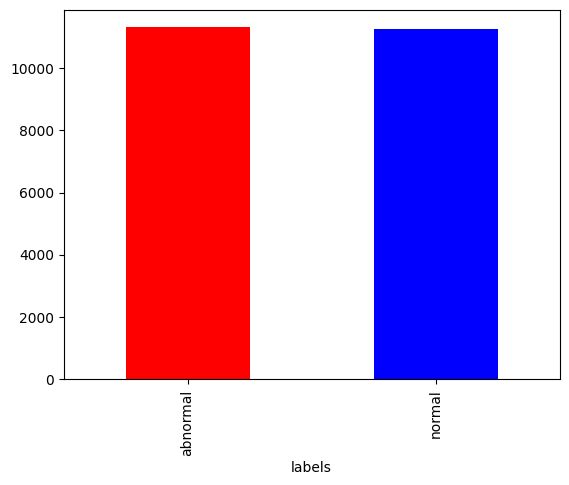

In [84]:
# Plotting  the Distribution of the Target Class in the Testing Set
data_test.labels.value_counts().plot(kind = 'bar', color = ['r','b'])

- Checking for missing values

In [85]:
# Missing values
data_test.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [86]:
data_test.dtypes

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

- Label Encoding the Testing dataset 

In [87]:
label = LabelEncoder()
data_test['protocol_type'] = label.fit_transform(data_test['protocol_type'])
data_test['service'] = label.fit_transform(data_test['service'])
data_test['flag'] = label.fit_transform(data_test['flag'])
data_test['labels'] = label.fit_transform(data_test['labels'])
data_test.sample(4)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
6322,0,1,23,9,259,4522,0,0,0,0,...,255,1.00,0.00,1.0,0.05,0.0,0.0,0.0,0.0,1
9932,0,1,46,5,0,0,0,0,0,0,...,15,0.06,0.07,0.0,0.00,1.0,1.0,0.0,0.0,0
1870,0,2,12,9,44,76,0,0,0,0,...,227,0.89,0.01,0.0,0.00,0.0,0.0,0.0,0.0,1
2066,0,0,15,9,520,0,0,0,0,0,...,255,1.00,0.00,1.0,0.00,0.0,0.0,0.0,0.0,0


In [88]:
data_test.dtypes

duration                         int64
protocol_type                    int32
service                          int32
flag                             int32
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [89]:
features_test = data_test.drop(['labels'], axis = 1)
target_test = data_test.loc[:, ['labels']]

In [90]:
# Merging into binary
target_test.head(10)

,labels
0,1
1,1
2,1
3,1
4,0
5,0
6,1
7,0
8,0
9,0


### Our datasets are preprocesseds, now we continue.

- Normalization/Scaling the Dataset

In [91]:
# Now we perform feature scaling/normalization using MinMAx just incase
# TRAIN
scaler = MinMaxScaler()

feature_scaled_train = scaler.fit_transform(features_train)
feature_scaled_train_df = pd.DataFrame(feature_scaled_train, columns = features_train.columns)
feature_scaled_train_df

# TEST
feature_scaled_test = scaler.fit_transform(features_test)
feature_scaled_test_df = pd.DataFrame(feature_scaled_test, columns=features_test.columns)
feature_scaled_test_df
#feature_scaled_train

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0.000092,0.5,0.784615,0.9,3.866255e-05,0.000092,0.0,0.0,0.0,0.0,...,0.704724,0.220472,0.11,0.02,0.01,0.04,0.00,0.0,0.87,0.0
1,0.000000,1.0,0.184615,0.9,7.162680e-07,0.000026,0.0,0.0,0.0,0.0,...,0.759843,0.606299,0.80,0.02,0.01,0.00,0.00,0.0,0.00,0.0
2,0.000000,1.0,0.184615,0.9,7.162680e-07,0.000016,0.0,0.0,0.0,0.0,...,1.000000,1.000000,1.00,0.00,0.01,0.00,0.00,0.0,0.00,0.0
3,0.036345,1.0,0.630769,0.9,2.307975e-06,0.000020,0.0,0.0,0.0,0.0,...,1.000000,0.003937,0.01,0.84,1.00,0.00,0.00,0.0,0.00,0.0
4,0.265597,0.5,0.630769,0.4,1.591707e-08,0.000000,0.0,0.0,0.0,0.0,...,1.000000,0.003937,0.01,0.68,1.00,0.00,0.00,0.0,1.00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0.000000,0.5,0.707692,0.1,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,...,1.000000,0.000000,0.00,1.00,0.00,0.00,0.09,0.0,0.91,1.0
22540,0.000000,0.5,0.353846,0.9,4.042935e-06,0.000442,0.0,0.0,0.0,0.0,...,0.102362,1.000000,1.00,0.00,0.04,0.04,0.00,0.0,0.00,0.0
22541,0.000000,0.5,0.707692,0.5,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,...,1.000000,0.094488,0.10,0.07,0.00,0.00,1.00,1.0,0.00,0.0
22542,0.000000,0.5,0.707692,0.4,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,...,1.000000,0.000000,0.00,0.58,0.57,0.00,0.00,0.0,0.58,1.0


### FEATURE SELECTION STAGE

- Using Chi-Square

In [92]:
# We normalized the scores to a specific range for further analysis
data_chi = SelectKBest(score_func = chi2)
data_chi.fit(feature_scaled_train, target_train)

data_chi_ = data_chi.scores_
scaler = StandardScaler()
chi2_scores_normalized = scaler.fit_transform(data_chi_.reshape(-1, 1)).ravel()

Table_score = pd.DataFrame(chi2_scores_normalized)
Table_names = pd.DataFrame(features_train.columns)
chi_table = pd.concat([Table_names, Table_score], axis = 1)
chi_table.columns = ['Features', 'Scores']
chi_table.sort_values(by = 'Scores', ascending  = False, inplace = True)
chi_table

,Features,Scores
38,dst_host_srv_serror_rate,2.382689
25,srv_serror_rate,2.297513
24,serror_rate,2.290770
37,dst_host_serror_rate,2.279904
11,logged_in,2.204520
32,dst_host_srv_count,1.508229
33,dst_host_same_srv_rate,1.205690
28,same_srv_rate,1.001324
22,count,0.373245
27,srv_rerror_rate,-0.076843


- Using Mutual Information

In [93]:
# We  normalized the scores to a specific range for further analysis
data_mi = SelectKBest(score_func = mutual_info_classif)
data_mi.fit(feature_scaled_train, target_train)

data_mi_ = data_mi.scores_
scaler = StandardScaler()
mi_scores_normalized = scaler.fit_transform(data_mi_.reshape(-1, 1)).ravel()

Table_score = pd.DataFrame(mi_scores_normalized)
Table_names = pd.DataFrame(features_train.columns)
mi_table = pd.concat([Table_names, Table_score], axis = 1)
mi_table.columns = ['Features', 'Scores']
mi_table.sort_values(by = 'Scores', ascending = False, inplace = True)
mi_table

,Features,Scores
4,src_bytes,2.559091
2,service,1.963449
5,dst_bytes,1.794344
3,flag,1.357890
28,same_srv_rate,1.343204
29,diff_srv_rate,1.303693
32,dst_host_srv_count,1.161011
33,dst_host_same_srv_rate,0.988492
11,logged_in,0.885825
37,dst_host_serror_rate,0.853410


- Selecting 28 features From Both Filter Methods

In [94]:
# Now from our methodology, we aim to cut off 70%. 70% of 40 is approximately 28
Top_70_chi = chi_table.head(28)
Top_70_mi =  mi_table.head(28)


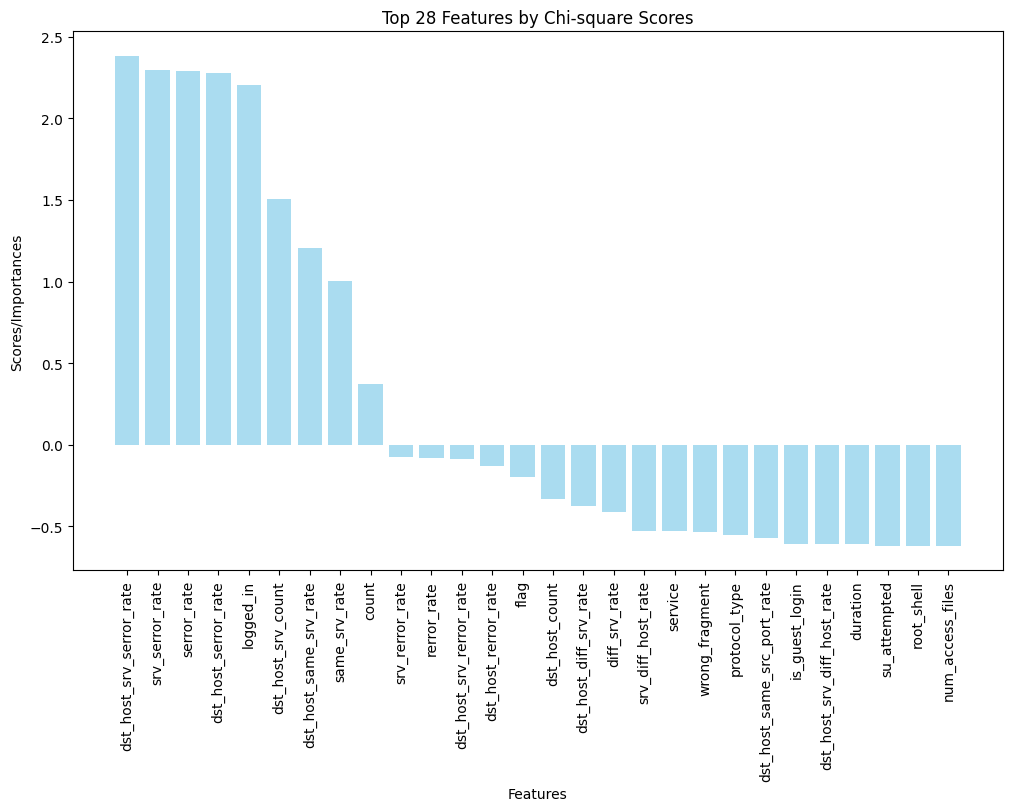

In [95]:
# Plotting the top 28 Chi-square scores
plt.figure(figsize=(12, 7))
plt.bar(Top_70_chi['Features'], Top_70_chi['Scores'], color='skyblue', alpha=0.7)
plt.xticks(rotation=90)
plt.title('Top 28 Features by Chi-square Scores')
plt.xlabel('Features')
plt.ylabel('Scores/Importances')
plt.show()

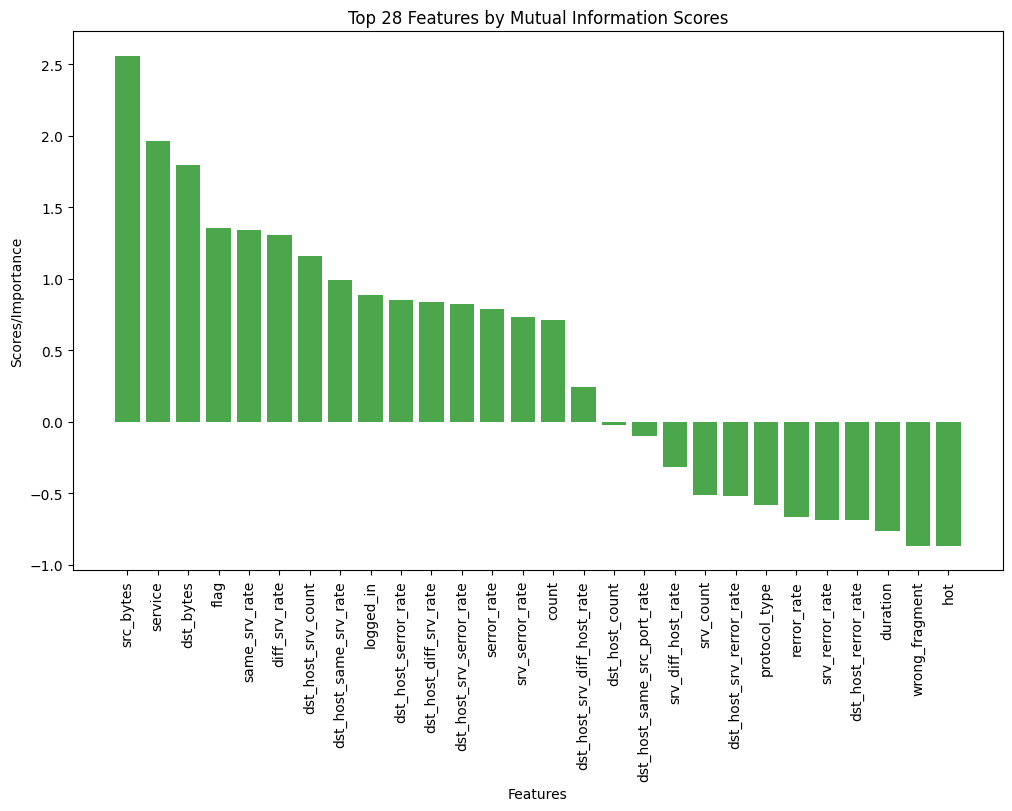

In [96]:
# Plotting the top 28 Mutual Information scores
plt.figure(figsize=(12, 7))
plt.bar(Top_70_mi['Features'], Top_70_mi['Scores'], color='green',  alpha=0.7)
plt.xticks(rotation=90)
plt.title('Top 28 Features by Mutual Information Scores')
plt.xlabel('Features')
plt.ylabel('Scores/Importance')
plt.show()

- Selected Features Merging

In [97]:
# Now from our methodology, we merge the selected features from chi-square and Mutual Information

merge_table = pd.concat([Top_70_chi , Top_70_mi], axis = 0)
merge_table.sort_values(by = 'Scores', ascending = False , inplace  = True)
merge_table 

,Features,Scores
4,src_bytes,2.559091
38,dst_host_srv_serror_rate,2.382689
25,srv_serror_rate,2.297513
24,serror_rate,2.290770
37,dst_host_serror_rate,2.279904
11,logged_in,2.204520
2,service,1.963449
5,dst_bytes,1.794344
32,dst_host_srv_count,1.508229
3,flag,1.357890


In [98]:
merge_table.shape

(56, 2)

- Handling Duplicates After Merging

In [99]:
'''We realised that there are duplicates of features in the dataframe, 
thus we wil drop the one with a lower rank''';
drop_duplicate_table = merge_table.drop_duplicates(subset = ['Features'], keep = 'first')
drop_duplicate_table

,Features,Scores
4,src_bytes,2.559091
38,dst_host_srv_serror_rate,2.382689
25,srv_serror_rate,2.297513
24,serror_rate,2.290770
37,dst_host_serror_rate,2.279904
11,logged_in,2.204520
2,service,1.963449
5,dst_bytes,1.794344
32,dst_host_srv_count,1.508229
3,flag,1.357890


In [100]:
drop_duplicate_table.shape

(32, 2)

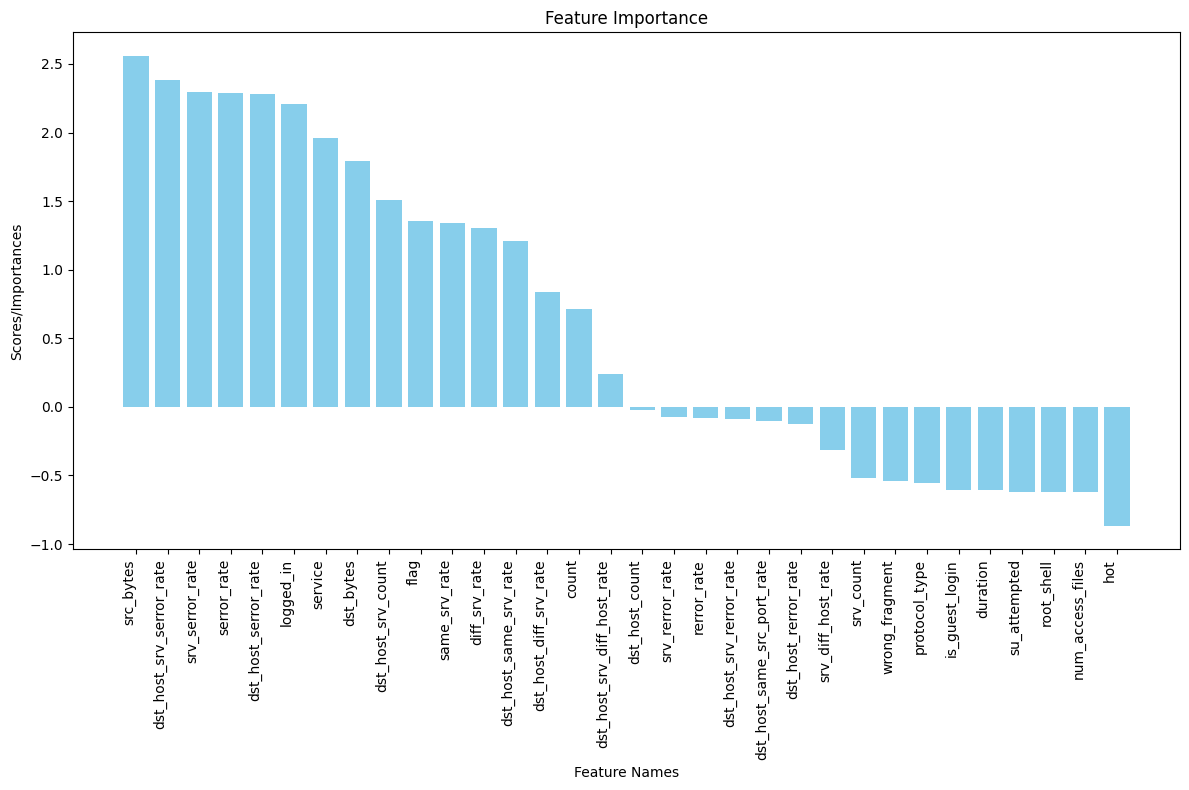

In [101]:
plt.figure(figsize = (12,8))
plt.bar(drop_duplicate_table['Features'], drop_duplicate_table['Scores'], color = 'skyblue')
plt.xlabel('Feature Names')
plt.ylabel('Scores/Importances')
plt.title('Feature Importance')
plt.xticks(rotation = 90, ha = 'right')
plt.tight_layout()
plt.show()

In [102]:
Top_70_selected = drop_duplicate_table['Features']
Top_70_selected = Top_70_selected.tolist()

In [103]:
# Selecting same features from the training and testing dataset

#Selecting features from training dataset
Features_Selected_train = feature_scaled_train_df[Top_70_selected]
Features_Selected_train


#Selected features from testing dataset
Features_Selected_test = feature_scaled_test_df[Top_70_selected]
Features_Selected_test 

,src_bytes,dst_host_srv_serror_rate,srv_serror_rate,serror_rate,dst_host_serror_rate,logged_in,service,dst_bytes,dst_host_srv_count,flag,...,srv_diff_host_rate,srv_count,wrong_fragment,protocol_type,is_guest_login,duration,su_attempted,root_shell,num_access_files,hot
0,3.866255e-05,0.0,0.0,0.00,0.00,1.0,0.784615,0.000092,0.220472,0.9,...,0.00,0.001957,0.0,0.5,0.0,0.000092,0.0,0.0,0.0,0.0
1,7.162680e-07,0.0,0.0,0.00,0.00,0.0,0.184615,0.000026,0.606299,0.9,...,0.01,0.526419,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,7.162680e-07,0.0,0.0,0.00,0.00,0.0,0.184615,0.000016,1.000000,0.9,...,0.00,0.236791,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,2.307975e-06,0.0,0.0,0.00,0.00,0.0,0.630769,0.000020,0.003937,0.9,...,0.00,0.003914,0.0,1.0,0.0,0.036345,0.0,0.0,0.0,0.0
4,1.591707e-08,0.0,0.0,0.00,0.00,0.0,0.630769,0.000000,0.003937,0.4,...,0.00,0.003914,0.0,0.5,0.0,0.265597,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0.000000e+00,0.0,0.0,0.06,0.09,0.0,0.707692,0.000000,0.000000,0.1,...,0.00,0.001957,0.0,0.5,0.0,0.000000,0.0,0.0,0.0,0.0
22540,4.042935e-06,0.0,0.0,0.00,0.00,1.0,0.353846,0.000442,1.000000,0.9,...,0.00,0.003914,0.0,0.5,0.0,0.000000,0.0,0.0,0.0,0.0
22541,0.000000e+00,1.0,1.0,1.00,1.00,0.0,0.707692,0.000000,0.094488,0.5,...,0.00,0.019569,0.0,0.5,0.0,0.000000,0.0,0.0,0.0,0.0
22542,0.000000e+00,0.0,0.0,0.00,0.00,0.0,0.707692,0.000000,0.000000,0.4,...,0.00,0.001957,0.0,0.5,0.0,0.000000,0.0,0.0,0.0,0.0


### Spilting data into train-test

In [104]:
def get_evaluation_scores(yt, yp):
    result = {}
    result['accuracy'] = accuracy_score(yt, yp),
    result['precision'] = precision_score(yt, yp),
    result['recall'] = recall_score(yt, yp),
    result['f1'] = f1_score(yt, yp), 
    
    return result

In [105]:
# Split data into training and testing sets

data_combined = pd.concat([Features_Selected_train, Features_Selected_test], axis = 0)
data_combined

target_combined = pd.concat([target_train, target_test], axis = 0)

X_train, X_test, y_train, y_test = train_test_split(data_combined, target_combined, test_size = .16, random_state = 42)


## Building Model

In [106]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [107]:
#Initailizing the classifiers
rf_classifier = RandomForestClassifier(n_estimators=150, random_state=42)
lr_classifier = LogisticRegression(max_iter=1000) 
ann_classifier = MLPClassifier(random_state = 42,
                             hidden_layer_sizes = (32, 8),
                             early_stopping = False,
                             solver = 'adam',
                             nesterovs_momentum = True,
                             momentum = 0.90,
                             max_iter = 500)


voting_classifier = VotingClassifier(estimators = [('rf', rf_classifier),  ('lr', lr_classifier), ('ann', ann_classifier)], voting  = 'hard')
voting_classifier.fit(X_train_scaled, y_train)

y_pred = voting_classifier.predict(X_test_scaled)

In [108]:
# Model Evaluation
get_evaluation_scores(y_test, y_pred)

{'accuracy': (0.9927618566679292,),
 'precision': (0.9901435104873049,),
 'recall': (0.9962710250714059,),
 'f1': (0.9931978169738195,)}

## Using all features

In [109]:
#Split data into training and testing sets

data_combined = pd.concat([feature_scaled_train_df, feature_scaled_test_df], axis = 0)
data_combined

target_combined = pd.concat([target_train, target_test], axis = 0)

X_train, X_test, y_train, y_test = train_test_split(data_combined, target_combined, test_size = .16, random_state = 42)


## Building Model

In [110]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [111]:
#Initailizing the classifiers
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
lr_classifier = LogisticRegression(max_iter=1000)
ann_classifier = MLPClassifier(random_state = 42,
                             hidden_layer_sizes = (32, 8),
                             early_stopping = False,
                             solver = 'adam',
                             nesterovs_momentum = True,
                             momentum = 0.90,
                             max_iter = 500)

voting_classifier = VotingClassifier(estimators = [('rf', rf_classifier), ('lr', lr_classifier), ('ann', ann_classifier)], voting  = 'soft')
voting_classifier.fit(X_train_scaled, y_train)

y_pred = voting_classifier.predict(X_test_scaled)

In [112]:
# Model Evaluation
get_evaluation_scores(y_test, y_pred)

{'accuracy': (0.994024323528174,),
 'precision': (0.9911713700141889,),
 'recall': (0.9976198032370676,),
 'f1': (0.9943851324634243,)}

In [113]:
def model_Evaluate(model):
  y_pred = model.predict(X_test)
  print(classification_report(y_test, y_pred))

  cf_matrix = confusion_matrix(y_test, y_pred)
  categories = ['Negative','Positive']
  group_names = ['True Neg','False Pos', 'False Neg','True Pos']

  group_percentages = ['{0:.2%}'.format(value) for value in cf_matrix.flatten() / np.sum(cf_matrix)]
  labels = [f'{v1}n{v2}' for v1, v2 in zip(group_names,group_percentages)]
  labels = np.asarray(labels).reshape(2,2)
  
  sns.heatmap(cf_matrix, annot = labels, cmap = 'Blues',fmt = '',
  xticklabels = categories, yticklabels = categories)
  plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
  plt.ylabel("Actual values" , fontdict = {'size':14}, labelpad = 10)
  plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     11159
           1       0.99      1.00      1.00     12604

    accuracy                           0.99     23763
   macro avg       0.99      0.99      0.99     23763
weighted avg       0.99      0.99      0.99     23763



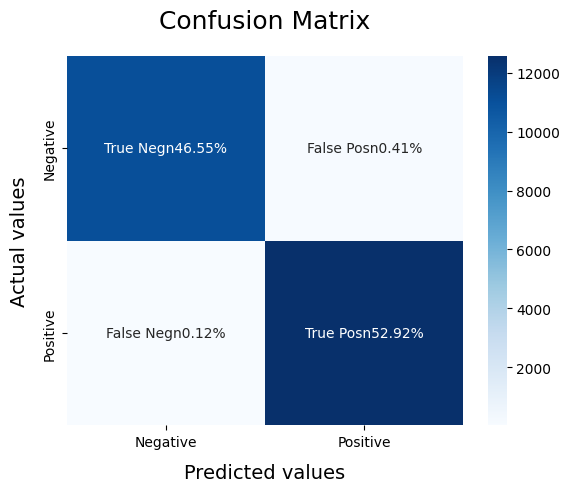

In [114]:
model_Evaluate(voting_classifier)